LeetCode 70 — Climbing Stairs

你爬一个有 n 级的楼梯，每次只能：

爬 1 级
或爬 2 级

问：爬到第 n 级一共有多少种方法？

In [1]:
# LeetCode 70 — Climbing Stairs

def climbStairs(n: int) -> int:
    if n <= 2:
        return n

    # dp[i] = dp[i-1] + dp[i-2]
    # creat a array to store the number of ways to reach each step i
    dp = [0] * (n + 1)
    dp[1] = 1
    dp[2] = 2

    for i in range(3, n + 1):
        dp[i] = dp[i - 1] + dp[i - 2]

    return dp[n]


n = 5
print(climbStairs(n))  # Output: 8

8


GridWorld 最大回报


grid = [
    [ 1, -1,  2,  5],
    [ 0,  3, -2,  1],
    [ 4, -1,  2, 10]
]

Agent 从左上角 (0,0) 出发，目标到右下角 (2,3)。

actions = [
    (1, 0),    # ↓ down
    (0, 1),    # → right
    (-1, 0),   # ↑ up
    (0, -1)    # ← left
]

In [ ]:
# dp[k][i][j]
# 表示在第 k 步时，位于位置 (i, j) 时的最大回报 （DP 思维 是 当状态信息不够时，增加状态维度）

# 当 s = (i, j) 时
# 选择action a = (di, dj) 时，状态转移为 s' = (i + di, j + dj)
# dp[k + 1][s'] = max(dp[k + 1][s'], dp[k][s] + reward(s, a))

grid = [
    [ 1, -1,  2,  5],
    [ 0,  3, -2,  1],
    [ 4, -1,  2, 10]
]

actions = [
    (-1, 0),   # ↑ up
    (1, 0),    # ↓ down
    (0, -1),   # ← left
    (0, 1),    # → right
]

def max_reward(grid : list[list[int]], k: int) -> int:
    m, n = len(grid), len(grid[0])
    # 初始化 -infinity 在 dp 数组中表示该状态不可达 表达[step][row][col]的最大回报
    dp = [[[-float('inf')] * n for _ in range(m)] for _ in range(k + 1)]
    dp[0][0][0] = grid[0][0]  # 初始状态

    for step in range(k):
        for i in range(m):
            for j in range(n):
                # 如果当前状态可达，则尝试四个方向移动 (为什么会有不可达的状态？因为有些状态可能在前几步中没有被访问到)
                if dp[step][i][j] != -float('inf'):
                    for di, dj in actions:
                        ni, nj = i + di, j + dj
                        if 0 <= ni < m and 0 <= nj < n:
                            # 计算新的回报 公式：dp + grid 的目的是在当前状态的基础上加上移动到新状态的奖励
                            new_reward = dp[step][i][j] + grid[ni][nj]
                            # 这个状态转移方程的意思是：在第 step + 1 步时，位于位置 (ni, nj) 的最大回报是当前的最大回报和从 (i, j) 移动到 (ni, nj) 的新回报中的较大值
                            dp[step + 1][ni][nj] = max(dp[step + 1][ni][nj], new_reward)

    # 返回在 k 步后到达终点的最大回报
    # 走完 K 步之后，不要求停在某个固定位置
    # 所以找所有位置中的最大 reward
    ans = -float('inf')

    for i in range(m):
        for j in range(n):
            ans = max(ans, dp[k][i][j])
            grip_position = (i, j)

    return ans, grip_position

# test
print(max_reward(grid, 8))

# print the trajectory of the maximum reward
def print_trajectory(grid: list[list[int]], k: int):
    m, n = len(grid), len(grid[0])
    dp = [[[-float('inf')] * n for _ in range(m)] for _ in range(k + 1)]
    dp[0][0][0] = grid[0][0]
    # 用于记录每一步的前驱状态
    prev = [[[(None, None)] * n for _ in range(m)] for _ in range(k + 1)]

    for step in range(k):
        for i in range(m):
            for j in range(n):
                if dp[step][i][j] != -float('inf'):
                    for di, dj in actions:
                        ni, nj = i + di, j + dj
                        if 0 <= ni < m and 0 <= nj < n:
                            new_reward = dp[step][i][j] + grid[ni][nj]
                            if new_reward > dp[step + 1][ni][nj]:
                                dp[step + 1][ni][nj] = new_reward
                                prev[step + 1][ni][nj] = (i, j)

    # 找到最大回报的位置
    max_reward_value = -float('inf')
    end_position = (None, None)
    for i in range(m):
        for j in range(n):
            if dp[k][i][j] > max_reward_value:
                max_reward_value = dp[k][i][j]
                end_position = (i, j)

    # 回溯路径
    trajectory = []
    current_position = end_position
    current_step = k

    while current_step > 0 and current_position != (None, None):
        trajectory.append(current_position)
        current_position = prev[current_step][current_position[0]][current_position[1]]
        current_step -= 1

    trajectory.reverse()
    return trajectory


print(print_trajectory(grid, 8))  # Output: [(0, 0), (1, 0), (1, 1), (2, 1), (2, 2), (2, 3)]

(32, (2, 3))
[(0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 2), (2, 3), (2, 2)]


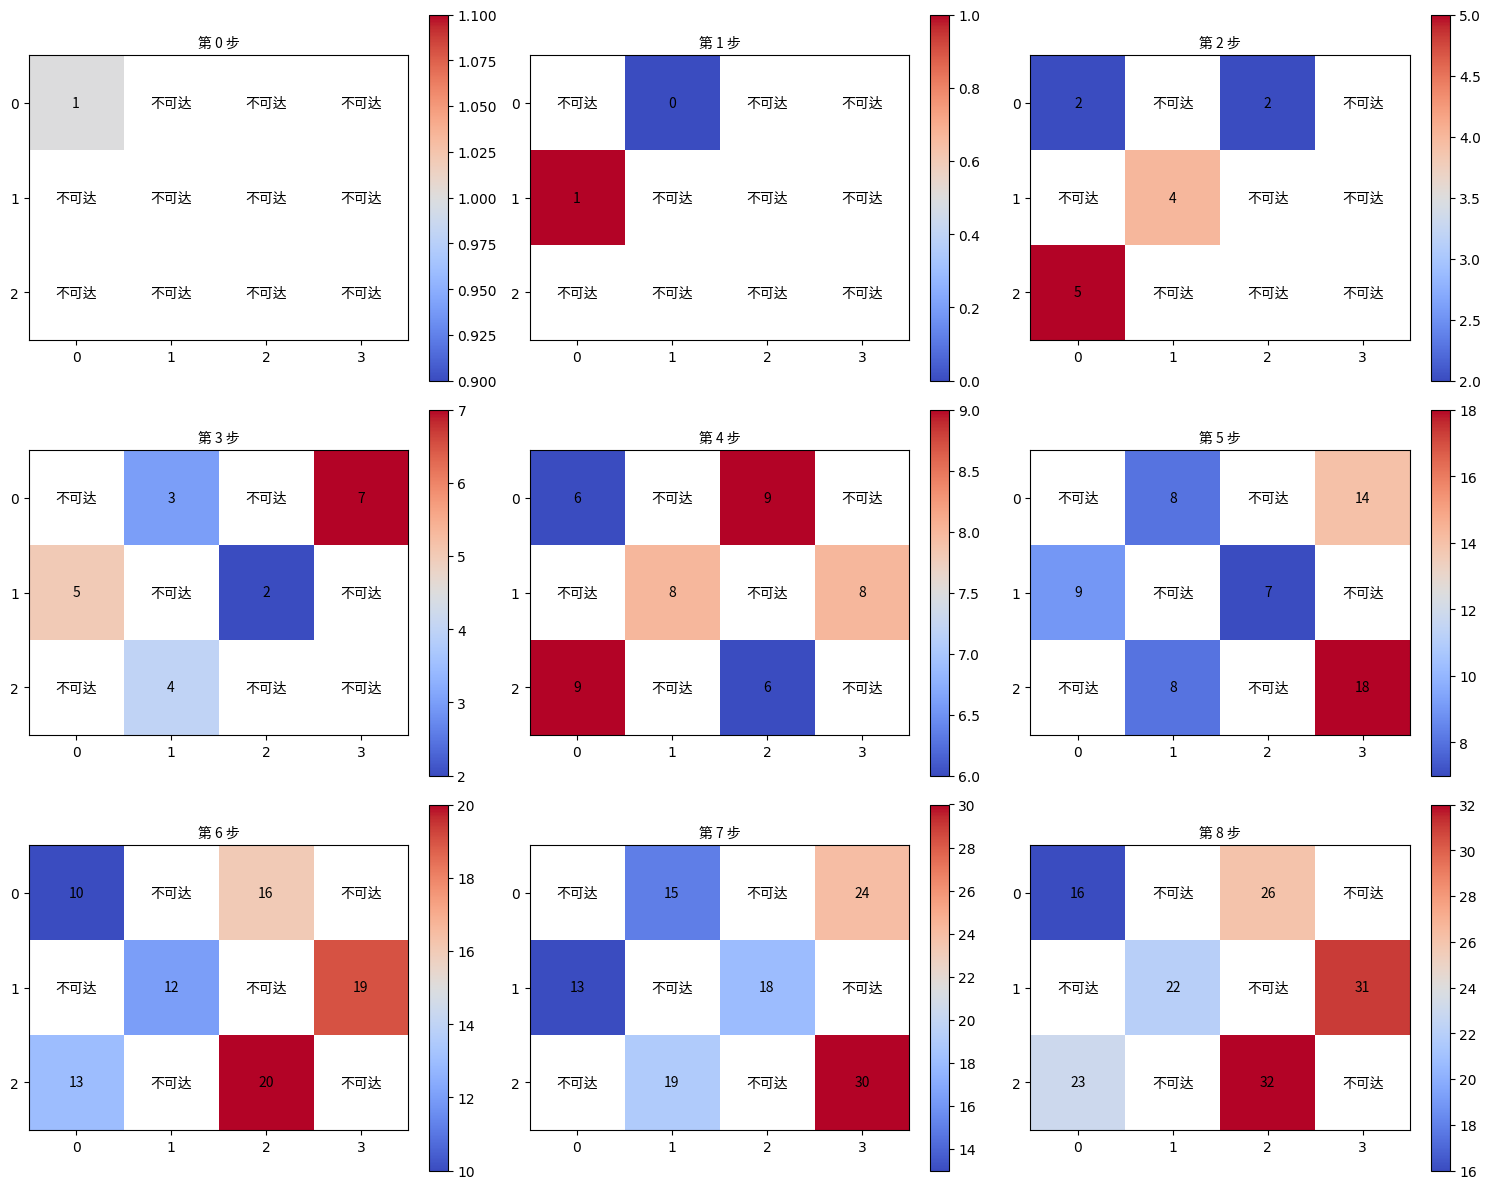

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

plt.rcParams["axes.unicode_minus"] = False

# 强制使用系统中实际存在的中文字体
zh_font = FontProperties(
    fname="/usr/share/fonts/google-noto-cjk/NotoSansCJK-Regular.ttc"
)
plt.rcParams["font.sans-serif"] = [
    "Noto Sans CJK SC",
    "SimHei",
    "WenQuanYi Zen Hei",
    "DejaVu Sans",
]


def visualize_max_reward(grid, actions, k=8):
    m, n_cols = len(grid), len(grid[0])
    neg_inf = -float("inf")

    dp = [
        [[neg_inf] * n_cols for _ in range(m)]
        for _ in range(k + 1)
    ]
    dp[0][0][0] = grid[0][0]

    for step in range(k):
        for i in range(m):
            for j in range(n_cols):
                current_reward = dp[step][i][j]
                if current_reward == neg_inf:
                    continue

                for di, dj in actions:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < m and 0 <= nj < n_cols:
                        new_reward = current_reward + grid[ni][nj]
                        dp[step + 1][ni][nj] = max(
                            dp[step + 1][ni][nj], new_reward
                        )

    # 第 0 步到第 k 步，共 k + 1 张图
    total_plots = k + 1
    ncols = 3
    nrows = math.ceil(total_plots / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5 * ncols, 4 * nrows),
        squeeze=False,
    )
    axes = axes.flatten()

    for step in range(total_plots):
        values = np.array(dp[step], dtype=float)
        masked_values = np.ma.masked_equal(values, neg_inf)

        image = axes[step].imshow(masked_values, cmap="coolwarm")
        axes[step].set_title(f"第 {step} 步", fontproperties=zh_font)
        axes[step].set_xticks(range(n_cols))
        axes[step].set_yticks(range(m))

        for i in range(m):
            for j in range(n_cols):
                value = values[i, j]
                text = "不可达" if value == neg_inf else str(int(value))
                axes[step].text(
                    j, i, text,
                    ha="center", va="center",
                    color="black", fontsize=10, fontproperties=zh_font,
                )

        fig.colorbar(image, ax=axes[step], fraction=0.046)

    for axis in axes[total_plots:]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()
    return dp


dp_result = visualize_max_reward(grid, actions, k=8)
